In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup  # for scraping
import time
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
import datetime as dt
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
DB_NAME = "punkDB.db"
import sqlite3
import pandas as pd

DB_NAME = "punkDB.db"   # or "punkDBFull.db" if that’s what you used

conn = sqlite3.connect(DB_NAME)
conn.execute("PRAGMA journal_mode=WAL;")

# Confirm tables exist
pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)


,name
0,Punks
1,PunkTrades
2,PunkIndexCSM
3,EthPrices


In [3]:
# Average number of actual trades per punk
pd.read_sql_query("""
SELECT AVG(cnt) AS avg_trades_per_punk
FROM (
    SELECT PunkID, COUNT(*) AS cnt
    FROM PunkTrades
    WHERE TType='Sold'
    GROUP BY PunkID
);
""", conn)



,avg_trades_per_punk
0,3.979839


In [4]:
# Median trades per punk
trade_counts = pd.read_sql_query("""
SELECT PunkID, COUNT(*) AS TradeCount
FROM PunkTrades
WHERE TType='Sold'
GROUP BY PunkID
""", conn)
trade_counts["TradeCount"].median()


3.0

In [5]:
# Trades per week
pd.read_sql_query("""
SELECT 
    strftime('%Y-%W', 
             substr(TDate,1,4)||'-'||substr(TDate,5,2)||'-'||substr(TDate,7,2)
    ) AS YearWeek,
    COUNT(*) AS TradesPerWeek
FROM PunkTrades
GROUP BY YearWeek
ORDER BY YearWeek;
""", conn)


,YearWeek,TradesPerWeek
0,2017-25,352
1,2017-26,92
2,2017-27,30
3,2017-28,37
4,2017-29,30
...,...,...
419,2026-02,6
420,2026-03,25
421,2026-04,5
422,2026-05,5


In [6]:
#Standard Deviation of Trades per punk
print("Std deviation:", trade_counts["TradeCount"].std())

Std deviation: 2.923379992605744


In [7]:
# Percentage of Punks that traded only once
one_trade_share = (trade_counts["TradeCount"] == 1).mean()
print("Share traded only once:", round(one_trade_share * 100, 2), "%")

Share traded only once: 22.58 %


In [8]:
trade_counts_sorted = trade_counts.sort_values("TradeCount", ascending=False)

top10_n = int(len(trade_counts_sorted) * 0.10)
top10_share = (
    trade_counts_sorted.head(top10_n)["TradeCount"].sum()
    / trade_counts_sorted["TradeCount"].sum()
)

print("Top 10% share:", round(top10_share * 100, 2), "%")

Top 10% share: 25.13 %


In [9]:
# Highest priced sale
pd.read_sql_query("""
SELECT PunkID, TAmt
FROM PunkTrades
WHERE TType='Sold' AND TAmt>0
ORDER BY TAmt DESC
LIMIT 1;
""", conn)

,PunkID,TAmt
0,7996,739356


In [10]:
# Most Frequently traded punk
pd.read_sql_query("""
SELECT PunkID, COUNT(*) AS TradeCount
FROM PunkTrades
GROUP BY PunkID
ORDER BY TradeCount DESC
LIMIT 1;
""", conn)


,PunkID,TradeCount
0,8091,149


In [11]:
# Top 5 traders + average net USD position
pd.read_sql_query("""
WITH trader_flows AS (
    SELECT TFrom AS Trader, TAmt AS USDFlow
    FROM PunkTrades 
    WHERE TAmt > 0 AND TFrom IS NOT NULL AND TFrom != ''
    
    UNION ALL
    
    SELECT TTo AS Trader, -TAmt AS USDFlow
    FROM PunkTrades 
    WHERE TAmt > 0 AND TTo IS NOT NULL AND TTo != ''
)
SELECT 
    Trader,
    COUNT(*) AS NumTrades,
    AVG(USDFlow) AS AvgNetPositionUSD
FROM trader_flows
GROUP BY Trader
ORDER BY NumTrades DESC
LIMIT 5;
""", conn)



,Trader,NumTrades,AvgNetPositionUSD
0,0xb4ea05,572,205.153846
1,punksotc…,228,65183.947368
2,0x717403,85,13.964706
3,Pranksy,72,11668.611111
4,0xe186a8,47,135411.063830


In [12]:
#Part 2
# Load FRED CSV
eth_df = pd.read_csv("CBETHUSD.csv")

eth_df.rename(columns={
    "observation_date": "DATE",
    "CBETHUSD": "CloseUSD"
}, inplace=True)

# Convert date
eth_df["DATE"] = pd.to_datetime(eth_df["DATE"],  format="%d-%m-%Y")

# Convert to YYYYMMDD integer
eth_df["TDate"] = eth_df["DATE"].dt.strftime("%Y%m%d").astype(int)

# Keep required columns
eth_df = eth_df[["TDate", "CloseUSD"]].dropna()

eth_df.head()



,TDate,CloseUSD
0,20160518,13.18
1,20160519,14.90
2,20160520,14.17
5,20160523,13.61
6,20160524,12.77


In [13]:
conn.execute("DROP TABLE IF EXISTS EthPrices;")

conn.execute("""
CREATE TABLE EthPrices (
    TDate INTEGER PRIMARY KEY,
    CloseUSD REAL
);
""")

eth_df.to_sql("EthPrices", conn, if_exists="append", index=False)

conn.commit()



In [14]:
pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)



,name
0,Punks
1,PunkTrades
2,PunkIndexCSM
3,EthPrices


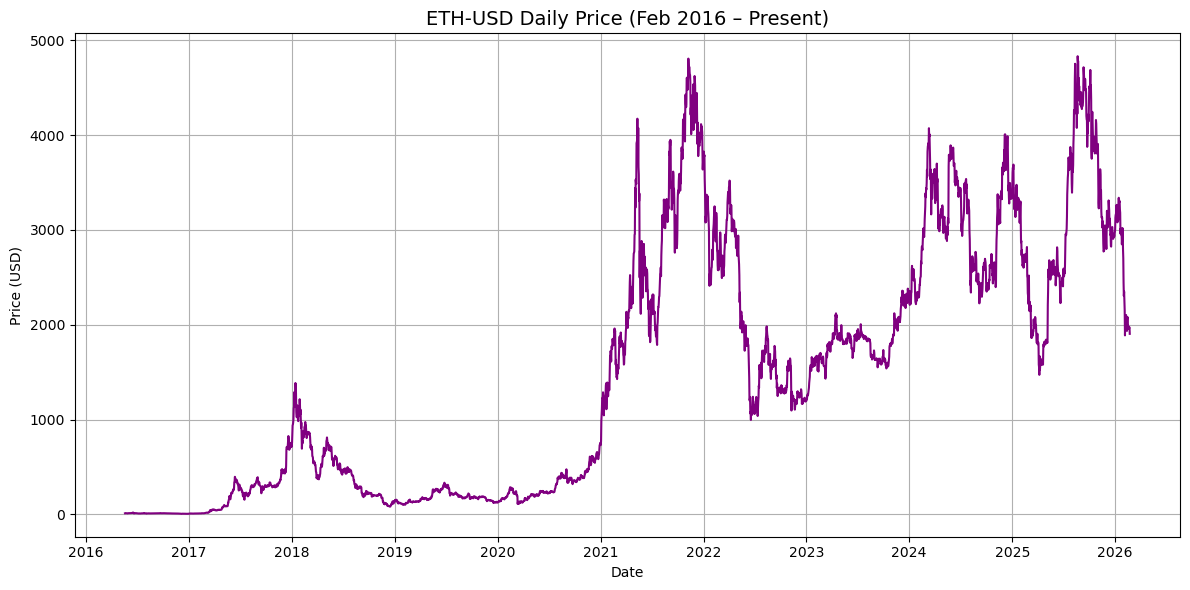

<Figure size 640x480 with 0 Axes>

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# Connect to DB
conn = sqlite3.connect("punkDB.db")

# Load ETH data from SQLite
eth = pd.read_sql_query(
    "SELECT TDate, CloseUSD FROM EthPrices ORDER BY TDate;",
    conn
)

# Convert integer date to datetime
eth["Date"] = pd.to_datetime(eth["TDate"].astype(str), format="%Y%m%d")

# Plot
plt.figure(figsize=(12,6))
plt.plot(eth["Date"], eth["CloseUSD"], color="purple", linewidth = 1.5)
plt.title("ETH-USD Daily Price (Feb 2016 – Present)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig('ETH-USD Daily Price (Feb 2016 - Present).png', dpi=300, bbox_inches='tight')


In [16]:
#Part 3

# Count sales per punk
sales_count = pd.read_sql_query("""
SELECT PunkID, COUNT(*) as NumSales
FROM PunkTrades
WHERE TType='Sold' AND TAmt > 0
GROUP BY PunkID
HAVING COUNT(*) >= 2;
""", conn)

eligible_punks = tuple(sales_count["PunkID"].tolist())

len(eligible_punks)


190

In [17]:
# TRUE Case–Shiller Repeat-Sales Index

import numpy as np
import statsmodels.api as sm

# Load Sold transactions
sold = pd.read_sql_query("""
SELECT TDate, PunkID, TAmt
FROM PunkTrades
WHERE TType='Sold'
AND TAmt > 0
ORDER BY PunkID, TDate;
""", conn)

sold["Date"] = pd.to_datetime(sold["TDate"].astype(str))
sold["LogPrice"] = np.log(sold["TAmt"])
sold = sold.sort_values(["PunkID","Date"])

# Build repeat-sales pairs
repeat_pairs = []

for punk, group in sold.groupby("PunkID"):
    group = group.sort_values("Date")
    if len(group) < 2:
        continue
    for i in range(1, len(group)):
        prev = group.iloc[i-1]
        curr = group.iloc[i]
        repeat_pairs.append({
            "Date1": prev["Date"],
            "Date2": curr["Date"],
            "LogReturn": curr["LogPrice"] - prev["LogPrice"]
        })

rs = pd.DataFrame(repeat_pairs)

# Convert to monthly periods
rs["Period1"] = rs["Date1"].dt.to_period("M")
rs["Period2"] = rs["Date2"].dt.to_period("M")

# Get all months
all_periods = sorted(
    set(rs["Period1"]).union(set(rs["Period2"]))
)

period_index = {p: i for i,p in enumerate(all_periods)}

# Build X matrix
T = len(all_periods)
N = len(rs)

X = np.zeros((N, T))

for i, row in rs.iterrows():
    X[i, period_index[row["Period2"]]] = 1
    X[i, period_index[row["Period1"]]] = -1

y = rs["LogReturn"].values

# Drop first column to avoid dummy trap
X = X[:,1:]

# Run regression
model_csm = sm.OLS(y, X).fit()

# Build full dummy vector
betas = np.zeros(T)
betas[1:] = model_csm.params

# Direct log index = betas
index_log = betas

# Normalize first period to 0
index_log = index_log - index_log[0]

# Convert to level
index_level = np.exp(index_log)

# Base = 100
index_level = 100 * index_level / index_level[0]

cs_index = pd.DataFrame({
    "Period": all_periods,
    "IndexLevel": index_level
})

print("Case-Shiller Index Built Successfully")

Case-Shiller Index Built Successfully


In [18]:
rs["Period1"].value_counts()

Period1
2021-08    71
2020-09    70
2021-02    57
2021-03    43
2021-04    41
           ..
2025-01     1
2019-08     1
2024-04     1
2020-03     1
2023-07     1
Freq: M, Name: count, Length: 92, dtype: int64

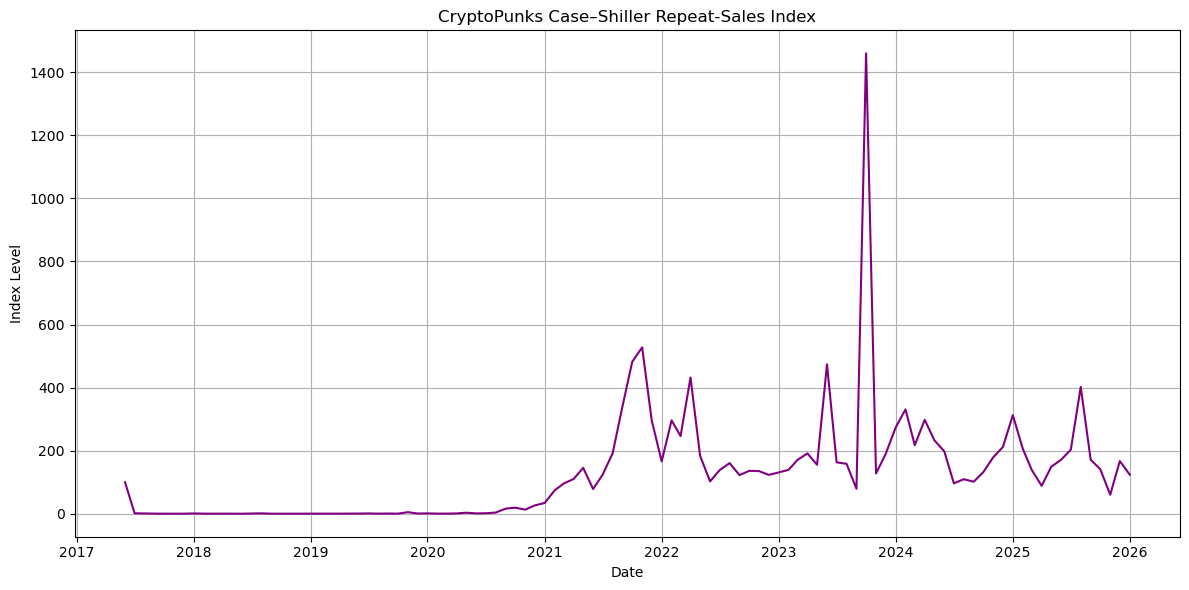

In [19]:
cs_index["Date"] = cs_index["Period"].dt.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(cs_index["Date"], cs_index["IndexLevel"], color="purple")
plt.title("CryptoPunks Case–Shiller Repeat-Sales Index")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# Rarity Measure
import math
punks = pd.read_sql_query(
    "SELECT PunkID, PunkType, AttributeVec FROM Punks;",
    conn
)

attr_len = len(punks["AttributeVec"].iloc[0])
counts = [0] * attr_len

for vec in punks["AttributeVec"]:
    for i, ch in enumerate(vec):
        if ch == "1":
            counts[i] += 1

def rarity_score(vec):
    present = [counts[i] for i, ch in enumerate(vec) if ch == "1"]
    if len(present) == 0:
        return None
    return -math.log(min(present))

punks["RarityScore"] = punks["AttributeVec"].apply(rarity_score)
print(punks)

import numpy as np

total_punks = len(punks)

# Sum-Based Rarity Score
def rarity_sum(vec):
    score = 0
    for i, ch in enumerate(vec):
        if ch == "1":
            prob = counts[i] / total_punks
            score += -np.log(prob)
    return score

punks["RaritySumScore"] = punks["AttributeVec"].apply(rarity_sum)

# Number of Traits (Collectibility proxy)
punks["NumTraits"] = punks["AttributeVec"].apply(lambda v: v.count("1"))

     PunkID  PunkType                                       AttributeVec  \
0      7879         4  0000000000000000000001000000000000000000000001...   
1      7880         4  0000000000000010000000000000000000000000000100...   
2      7881         4  0000000000000000000000000100000000000000000000...   
3      7882         3  0000000000000000000000000000010000000000010000...   
4      7883         4  0000000000000000000000000000000000000000000000...   
..      ...       ...                                                ...   
298    8177         4  0000000000000000000000000000000000000000000000...   
299    8178         4  0000000000000000000000000000000000000000000001...   
300    8179         4  0000000000000000000000000000000000000010000100...   
301    8180         4  0000000000000000000000000000000000000000000000...   
302    8181         4  0000000001000000000000000000000000000000000000...   

     RarityScore  
0      -2.197225  
1      -1.791759  
2      -1.791759  
3      -1.9

In [21]:
trades = pd.read_sql_query("""
SELECT TDate, PunkID, TAmt, TType
FROM PunkTrades
WHERE TType IN ('Sold', 'Offered')
AND TAmt > 0;
""", conn)

eth = pd.read_sql_query("""
SELECT TDate, CloseUSD FROM EthPrices;
""", conn)


In [22]:
df = trades.merge(
    punks[["PunkID", "PunkType", "RarityScore", "RaritySumScore", "NumTraits"]],
    on="PunkID",
    how="left"
)

df = df.merge(eth, on="TDate", how="left")

# Add Year column
df["Year"] = pd.to_datetime(df["TDate"].astype(str)).dt.year

# Prepare Case-Shiller yearly index
cs_index["Year"] = cs_index["Period"].dt.year

# Merge yearly Case-Shiller index
df = df.merge(
    cs_index[["Year", "IndexLevel"]],
    on="Year",
    how="left"
)

df["LogPriceUSD"] = np.log(df["TAmt"])
df["LogETHUSD"] = np.log(df["CloseUSD"])
df["LogIndex"] = np.log(df["IndexLevel"])

df = df.dropna().copy()

type_dummies = pd.get_dummies(
    df["PunkType"],
    drop_first=True
)

df = pd.concat([df, type_dummies], axis=1)

# Split 2/3 by date
unique_dates = sorted(df["TDate"].unique())

cut = int(len(unique_dates) * (2/3))

is_dates = unique_dates[:cut]
os_dates = unique_dates[cut:]

is_df = df[df["TDate"].isin(is_dates)].copy()
os_df = df[df["TDate"].isin(os_dates)].copy()


df.head()

,TDate,PunkID,TAmt,TType,PunkType,RarityScore,RaritySumScore,NumTraits,CloseUSD,Year,IndexLevel,LogPriceUSD,LogETHUSD,LogIndex,4
0,20170626,7926,13,Sold,4,-2.302585,11.110894,4,252.99,2017,100.000000,2.564949,5.53335,4.605170,True
1,20170626,7926,13,Sold,4,-2.302585,11.110894,4,252.99,2017,1.326700,2.564949,5.53335,0.282695,True
2,20170626,7926,13,Sold,4,-2.302585,11.110894,4,252.99,2017,0.338509,2.564949,5.53335,-1.083206,True
3,20170626,7926,13,Sold,4,-2.302585,11.110894,4,252.99,2017,0.129633,2.564949,5.53335,-2.043052,True
4,20170626,7926,13,Sold,4,-2.302585,11.110894,4,252.99,2017,0.088117,2.564949,5.53335,-2.429093,True


In [23]:
# Hedonic Regression
# Convert boolean dummies to int
# Define regression columns FIRST
X_cols = ["RaritySumScore", "NumTraits", "LogIndex", "LogETHUSD"] + list(type_dummies.columns)

# Convert boolean dummies to int
is_df[type_dummies.columns] = is_df[type_dummies.columns].astype(int)

# Ensure numeric
is_df[X_cols] = is_df[X_cols].apply(pd.to_numeric, errors='coerce')
is_df["LogPriceUSD"] = pd.to_numeric(is_df["LogPriceUSD"], errors='coerce')

# Drop missing
is_df = is_df.dropna(subset=X_cols + ["LogPriceUSD"])

# Build regression
X = sm.add_constant(is_df[X_cols])
y = is_df["LogPriceUSD"]

hedonic_model = sm.OLS(y, X).fit()

print(hedonic_model.summary())



                            OLS Regression Results                            
Dep. Variable:            LogPriceUSD   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.866
Method:                 Least Squares   F-statistic:                 5.585e+04
Date:                Thu, 26 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:27:18   Log-Likelihood:                -59018.
No. Observations:               43227   AIC:                         1.180e+05
Df Residuals:                   43221   BIC:                         1.181e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -5.8197      0.053   -110.

In [24]:
# Part 4
# Convert TDate to datetime
os_df["Date"] = pd.to_datetime(os_df["TDate"].astype(str))

# Identify first date in OS
start_os = os_df["Date"].min()

# Define 6 month window
end_window = start_os + pd.DateOffset(months=6)

trade_window = os_df[
    (os_df["Date"] >= start_os) &
    (os_df["Date"] <= end_window)
].copy()

len(trade_window)


1932

In [25]:
# Ensure numeric types for trading window
trade_window[X_cols] = trade_window[X_cols].apply(pd.to_numeric, errors='coerce')
trade_window[type_dummies.columns] = trade_window[type_dummies.columns].astype(int)
trade_window = trade_window.dropna(subset=X_cols)

X_trade = trade_window[X_cols].copy()
X_trade = sm.add_constant(X_trade, has_constant='add')

trade_window["PredictedLogPrice"] = hedonic_model.predict(X_trade)
trade_window["PredictedPrice"] = np.exp(trade_window["PredictedLogPrice"])
print(trade_window["PredictedLogPrice"])



18161    11.490816
18162    11.508473
18163    11.567239
18164    11.599712
18165    11.539954
           ...    
37857    11.471401
37858    11.272623
37859    12.107032
37860    11.409709
37861    11.522145
Name: PredictedLogPrice, Length: 1932, dtype: float64


In [28]:
trade_window["MispricingPct"] = (trade_window["PredictedPrice"] - trade_window["TAmt"]
                                )/ trade_window['PredictedPrice'] 
trade_window["MispricingPct"] = trade_window["MispricingPct"].round(3)


In [33]:
THRESHOLD = 0.20   # 10%

trade_window["Signal"] = 0

trade_window.loc[
    trade_window["MispricingPct"] > THRESHOLD,
    "Signal"
] = 1

trade_window.loc[
    trade_window["MispricingPct"] < -THRESHOLD,
    "Signal"
] = -1

trade_window["SignalLabel"] = trade_window["Signal"].map({
    1: "BUY (Undervalued)",
    -1: "SHORT (Overvalued)",
    0: "No Trade"
})

In [34]:
trade_window = trade_window.sort_values("Date")

trade_window = trade_window.drop_duplicates(
    subset=["PunkID", "Date", "TAmt", "TType"]
)

returns = []
open_positions = set()

for idx, row in trade_window.iterrows():

    punk = row["PunkID"]

    # Skip if already holding position in this punk
    if punk in open_positions:
        continue

    if row["Signal"] == 0:
        continue

    entry_price = row["TAmt"]
    entry_date = row["Date"]
    signal = row["Signal"]

    # Find next SOLD trade after entry
    future_sales = os_df[
        (os_df["PunkID"] == punk) &
        (pd.to_datetime(os_df["TDate"].astype(str)) > entry_date) &
        (os_df["TType"] == "Sold")
    ].sort_values("TDate")

    if len(future_sales) == 0:
        continue

    exit_price = future_sales.iloc[0]["TAmt"]

    if signal == 1:
        ret = (exit_price - entry_price) / entry_price
    else:
        ret = (entry_price - exit_price) / entry_price

    returns.append(ret)

    # Mark as closed immediately (since we exit at next sale)
avg_return = np.mean(returns)
print("Closed trades:", len(returns))
print("Average return:", avg_return)

Closed trades: 121
Average return: -0.05004729459778328


In [35]:
print("Min mispricing:", trade_window["MispricingPct"].min())
print("Max mispricing:", trade_window["MispricingPct"].max())
print("Number of BUY:", (trade_window["Signal"] == 1).sum())
print("Number of SHORT:", (trade_window["Signal"] == -1).sum())

Min mispricing: -1.696
Max mispricing: 0.413
Number of BUY: 11
Number of SHORT: 118
